# PV structural-aliasing — full analysis
Ontology → layer probe → regime sweep → resample sweep → Bayesian analysis + mitigation.
One notebook, one run.

In [1]:
import torch, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
from sklearn.metrics import mean_absolute_error
import pymc as pm
import arviz as az

sys.path.insert(0, ".")
import pv_data as pv

CSV_PATH = "../data/dataset/Dataset-SolarTechLabEngineered.csv"
ONTOLOGY = "./ontology_pv.json"
OUT = Path("../outputs/ontology_probing"); OUT.mkdir(parents=True, exist_ok=True)
np.random.seed(42); torch.manual_seed(42)

pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model; cfg = model.config.chronos_config
P, S_DEF, PRED_LEN = cfg["input_patch_size"], cfg["input_patch_stride"], cfg["prediction_length"]
N_ENC, N_DEC = len(model.encoder.block), len(model.decoder.block)
T_ctx = 512
print(f"P={P}  S={S_DEF}  pred_len={PRED_LEN}  enc={N_ENC}  dec={N_DEC}")


/Users/federicosabbadini/Desktop/Workspaces/federicosabbadini/patchAliasing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


P=16  S=16  pred_len=64  enc=4  dec=4


In [2]:
def cut_into_patches(x, P, S):
    return np.stack([x[i:i+P] for i in range(0, len(x)-P+1, S)])

def adjacent_cos(M):
    M = np.asarray(M, float)
    s = [np.dot(M[i],M[i+1])/(np.linalg.norm(M[i])*np.linalg.norm(M[i+1])+1e-12) for i in range(len(M)-1)]
    return float(np.mean(s)) if s else np.nan

def effective_rank(M):
    M = np.asarray(M, float); M = M - M.mean(0, keepdims=True)
    sv = np.linalg.svd(M, compute_uv=False); sv = sv[sv > 1e-12]
    if sv.size == 0: return 0.0
    p = sv / sv.sum(); return float(np.exp(-(p*np.log(p)).sum()))

def as_matrix(t):
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy()
    return a[0] if a.ndim == 3 else a

def stage_metrics(M):
    n = len(M)
    if n < 3: return dict(n_tokens=n, redundancy=np.nan, eff_rank=np.nan)
    return dict(n_tokens=n, redundancy=adjacent_cos(M), eff_rank=effective_rank(M))

def forward_capture(context, stride=S_DEF):
    cap, handles = {}, []
    model.patch.patch_stride = stride
    def save(key, use_input=False):
        def hook(m, i, o): cap[key] = as_matrix(i[0] if use_input else o)
        return hook
    if hasattr(model, "instance_norm"):
        handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    for k, b in enumerate(model.encoder.block): handles.append(b.register_forward_hook(save(f"enc{k}")))
    for k, b in enumerate(model.decoder.block): handles.append(b.register_forward_hook(save(f"dec{k}")))
    if hasattr(model, "output_patch_embedding"):
        handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad(): fc = pipeline.predict(x, prediction_length=PRED_LEN)
    for h in handles: h.remove()
    model.patch.patch_stride = S_DEF
    scaled_1d = cap.pop("scaled", None)
    cap = {"input": cut_into_patches(context, P, stride),
           "scaled": cut_into_patches(np.asarray(scaled_1d).ravel(), P, stride)
                     if scaled_1d is not None else cut_into_patches(context, P, stride), **cap}
    return fc, cap

def embed_redundancy_and_mae(sig, stride=S_DEF):
    cap = {}; model.patch.patch_stride = stride
    h = model.input_patch_embedding.register_forward_hook(
        lambda m, i, o: cap.__setitem__("e", o.detach().cpu().numpy()[0]))
    ctx = sig[:len(sig)-PRED_LEN]
    with torch.no_grad():
        fc = pipeline.predict(torch.tensor(np.asarray(ctx, np.float32)).unsqueeze(0), prediction_length=PRED_LEN)
    h.remove(); model.patch.patch_stride = S_DEF
    pred = fc[0].median(dim=0).values.numpy()
    return adjacent_cos(cap["e"]), mean_absolute_error(sig[len(ctx):len(ctx)+PRED_LEN], pred)

def patched_redundancy(w, P, S):
    return adjacent_cos(cut_into_patches(np.asarray(w, float), P, S))

def patched_redundancy_jitter(w, P, S, seed=None):
    rng = np.random.default_rng(seed)
    delta = int(rng.integers(0, P))
    return adjacent_cos(cut_into_patches(np.asarray(w, float)[delta:], P, S))


In [3]:
ts, power = pv.load_power(CSV_PATH)
print(f"Dataset: {len(power):,} samples  (~{len(power)//1440} days at 1-min resolution)")


Dataset: 520,747 samples  (~361 days at 1-min resolution)


## 1 — Semantic layer: ontology → concept observability
Maps every PV domain concept to its `cpp = P·dt/period` and structural-aliasing risk.

In [4]:
DT_MIN = 1
onto = pv.load_ontology(ONTOLOGY)
ct   = pv.concept_table(onto, P, dt_min=DT_MIN)
print(ct.to_string(index=False))
print("\nBlind-spot concepts at dt=1 min:", list(ct[ct.risk.str.startswith("BLIND")].concept))


            concept  kind          owl_class  period_min    cpp  period_samples                       risk                                              meaning
     seasonal_cycle cycle   TimeSeriesSignal    525600.0 0.0000        525600.0             near-DC (safe)        annual irradiance and PV production variation
      diurnal_cycle cycle   TimeSeriesSignal      1440.0 0.0111          1440.0             near-DC (safe)                        day-night PV production cycle
cloud_intermittency cycle   TimeSeriesSignal         8.0 2.0000             8.0         BLIND SPOT (cpp~2) fast cloud-induced fluctuations affecting generation
         night_zero state    Nighttime_Array         NaN    NaN             NaN non-periodic (state/event)                  zero PV production during nighttime
          clear_sky state     ClearSky_Array         NaN    NaN             NaN non-periodic (state/event)                optimal PV production under clear sky
  inverter_clipping state     Clipping_A

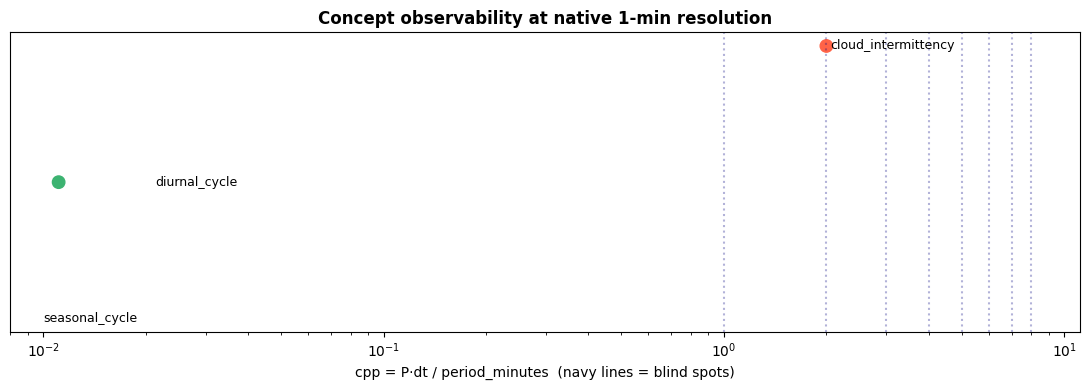

In [5]:
per = ct.dropna(subset=["cpp"])
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(per["cpp"], range(len(per)), s=80,
           color=["tomato" if r.startswith("BLIND") else "mediumseagreen" for r in per["risk"]])
for y, (_, r) in enumerate(per.iterrows()):
    ax.text(r["cpp"]*1.02+0.01, y, r["concept"], va="center", fontsize=9)
for k in range(1, P//2+1): ax.axvline(k, color="navy", ls=":", alpha=.3)
ax.set_xscale("log"); ax.set_yticks([])
ax.set_xlabel("cpp = P·dt / period_minutes  (navy lines = blind spots)")
ax.set_title("Concept observability at native 1-min resolution", fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"PV_1_concepts.png", dpi=140, bbox_inches="tight"); plt.show()


## 2 — Single-window layer probe
One real regime window through every Chronos stage. Redundancy → 1 means the stage has collapsed the signal to identical tokens (eaten). Decoder stages have NaN because the decoder runs on a single query token.

Regime start indices: {'night_zero': 0, 'clear_day': 316800, 'cloudy_day': 134112}
regime=cloudy_day  dominant cpp=0.188  blind-band energy=0.27


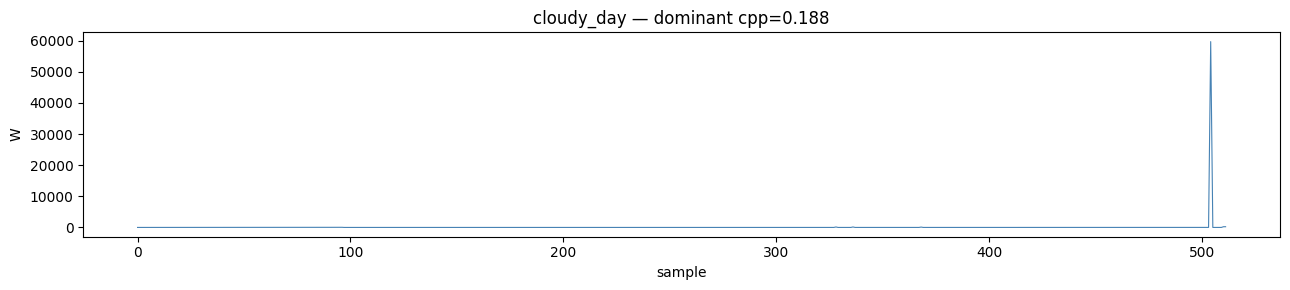

In [6]:
windows = pv.find_regime_windows(power, T=T_ctx + PRED_LEN + 8*P)
print("Regime start indices:", {k: int(v) if v is not None else None for k,v in windows.items()})

REGIME = "cloudy_day"      # <-- change to "clear_day" or "night_zero" to explore
start  = windows[REGIME]
signal = power[start:start+T_ctx+PRED_LEN].astype(float)
ctx    = signal[:T_ctx]
dom    = pv.dominant_cpp(ctx, P)
bb     = pv.blind_band_fraction(ctx, P)
print(f"regime={REGIME}  dominant cpp={dom:.3f}  blind-band energy={bb:.2f}")

plt.figure(figsize=(13,3))
plt.plot(ctx, lw=0.8, color="steelblue")
plt.title(f"{REGIME} — dominant cpp={dom:.3f}"); plt.xlabel("sample"); plt.ylabel("W")
plt.tight_layout(); plt.show()


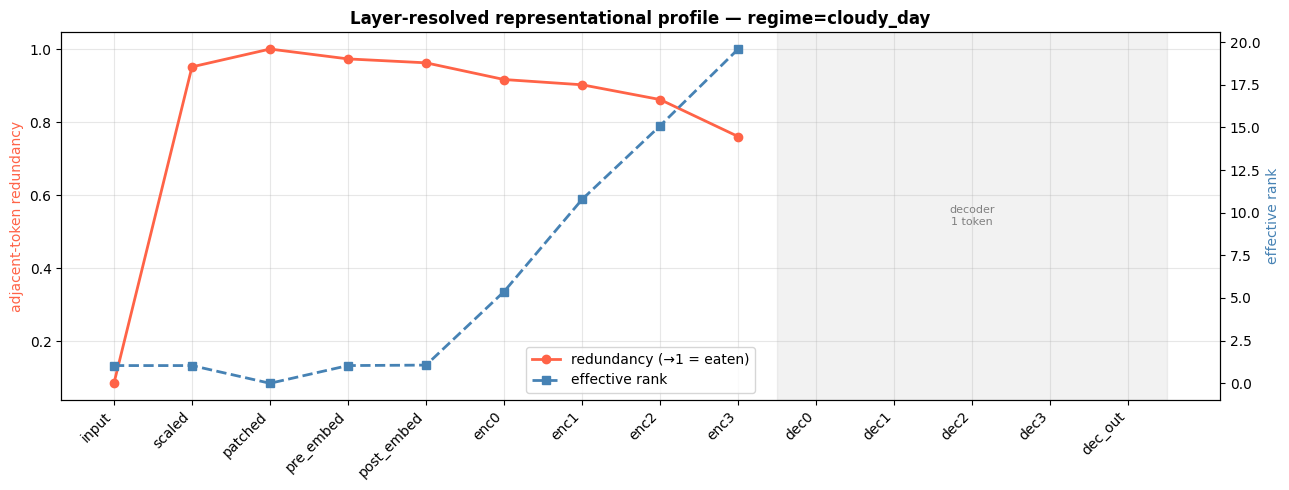

,stage,n_tokens,redundancy,eff_rank
0,input,32,0.084790,1.038887
1,scaled,32,0.951225,1.038887
2,patched,32,1.000000,0.000000
3,pre_embed,32,0.972985,1.038887
4,post_embed,32,0.962261,1.066165
5,enc0,33,0.916519,5.376044
6,enc1,33,0.902142,10.780623
7,enc2,33,0.861666,15.095861
8,enc3,33,0.760417,19.593021
9,dec0,1,NaN,NaN


In [7]:
forecast, cap = forward_capture(ctx)
STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
STAGES = [s for s in STAGES if s in cap]
prof   = pd.DataFrame([{"stage":s, **stage_metrics(cap[s])} for s in STAGES])

fig, ax = plt.subplots(figsize=(13,5)); ax2 = ax.twinx()
xs  = np.arange(len(STAGES))
few = prof["redundancy"].isna().values
if few.any():
    ax.axvspan(xs[few].min()-0.5, xs[few].max()+0.5, color="grey", alpha=0.10)
    ax.text(xs[few].mean(), 0.5, "decoder\n1 token", ha="center", va="center",
            fontsize=8, color="grey", transform=ax.get_xaxis_transform())
ax.plot(xs, prof["redundancy"], "o-", color="tomato", lw=2, label="redundancy (→1 = eaten)")
ax2.plot(xs, prof["eff_rank"],  "s--",color="steelblue", lw=2, label="effective rank")
ax.set_xticks(xs); ax.set_xticklabels(STAGES, rotation=45, ha="right")
ax.set_ylabel("adjacent-token redundancy", color="tomato")
ax2.set_ylabel("effective rank", color="steelblue")
ax.set_title(f"Layer-resolved representational profile — regime={REGIME}", fontweight="bold")
l1,a1=ax.get_legend_handles_labels(); l2,a2=ax2.get_legend_handles_labels(); ax.legend(l1+l2,a1+a2)
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT/"PV_2_layer_profile.png", dpi=140, bbox_inches="tight"); plt.show()
prof


## 3 — Spectral round-trip
Does the forecast preserve the spectral content that was in the context? Blind-spot energy lost in the forecast = the signal was invisible to the model.

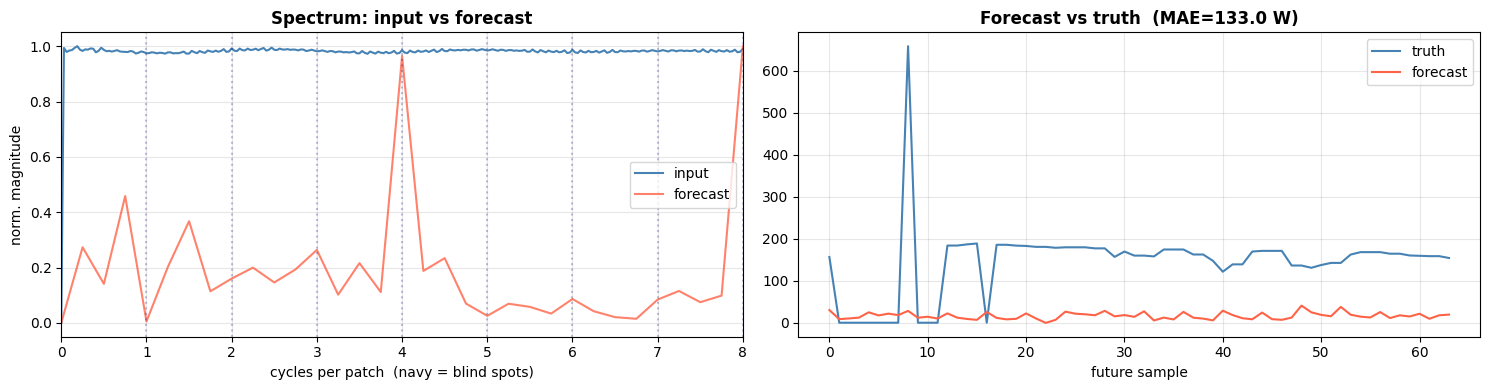

Blind-band energy: input=0.27 -> forecast=0.72  (retained)
Blind-spot concepts: ['cloud_intermittency']


In [8]:
pred  = forecast[0].median(dim=0).values.numpy()
truth = signal[T_ctx:T_ctx+PRED_LEN]

def spec(x):
    x = np.asarray(x, float) - np.mean(x)
    return np.fft.rfftfreq(len(x))*P, np.abs(np.fft.rfft(x))

cin,mi = spec(ctx); cout,mo = spec(pred)
fig,(a0,a1) = plt.subplots(1,2,figsize=(15,4))
a0.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
a0.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.8, label="forecast")
for k in range(1, P//2+1): a0.axvline(k, color="navy", ls=":", alpha=.25)
a0.set_xlim(0, P/2); a0.set_xlabel("cycles per patch  (navy = blind spots)")
a0.set_ylabel("norm. magnitude"); a0.set_title("Spectrum: input vs forecast", fontweight="bold")
a0.legend(); a0.grid(alpha=.3)
a1.plot(truth, color="steelblue", label="truth"); a1.plot(pred, color="tomato", label="forecast")
a1.set_title(f"Forecast vs truth  (MAE={np.mean(np.abs(truth-pred)):.1f} W)", fontweight="bold")
a1.set_xlabel("future sample"); a1.legend(); a1.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"PV_3_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()

bb_in  = pv.blind_band_fraction(ctx, P)
bb_out = pv.blind_band_fraction(pred, P)
risky  = list(ct[ct.risk.str.startswith("BLIND")].concept)
print(f"Blind-band energy: input={bb_in:.2f} -> forecast={bb_out:.2f}  "
      f"({'LOST' if bb_out < 0.5*bb_in else 'retained'})")
print(f"Blind-spot concepts: {risky}")


## 4 — Regime sweep
Run many real windows across all three regimes. Key metric: `blind_frac` (energy on blind-spot cpp bands). Note: forecast MAE is confounded (integer-cpp signals are trivially periodic).

In [9]:
W = T_ctx + PRED_LEN
def hi_energy(seg, hi_period=16):
    s = seg - seg.mean()
    if np.allclose(s, 0): return 0.0
    mag = np.abs(np.fft.rfft(s))**2; f = np.fft.rfftfreq(len(s))
    return mag[f > 1.0/hi_period].sum()/(mag.sum()+1e-9)

starts = range(0, len(power)-W, W)
means  = {s: power[s:s+W].mean() for s in starts}
thr    = np.quantile(list(means.values()), 0.90)
rows   = []
for s in starts:
    seg = power[s:s+W].astype(float)
    if seg.std() < 1e-6 and seg.mean() < 1e-6: regime = "night_zero"
    elif means[s] >= thr: regime = "cloudy_day" if hi_energy(seg) > 0.2 else "clear_day"
    else: continue
    if sum(r["regime"]==regime for r in rows) >= 20: continue   # cap per regime
    red, mae = embed_redundancy_and_mae(seg)
    rows.append({"regime":regime,"start":s,"redundancy":red,"mae":mae,
                 "blind_frac":pv.blind_band_fraction(seg[:T_ctx],P),
                 "dom_cpp":pv.dominant_cpp(seg[:T_ctx],P)})
df_reg = pd.DataFrame(rows)
print(df_reg.groupby("regime").agg(n=("mae","size"), redundancy=("redundancy","mean"),
                                   blind_frac=("blind_frac","mean"), mae=("mae","mean")).round(3))


             n  redundancy  blind_frac     mae
regime                                        
clear_day   20       0.959       0.012   7.748
cloudy_day  10       0.767       0.187  32.001
night_zero  20       1.000       0.000   0.000


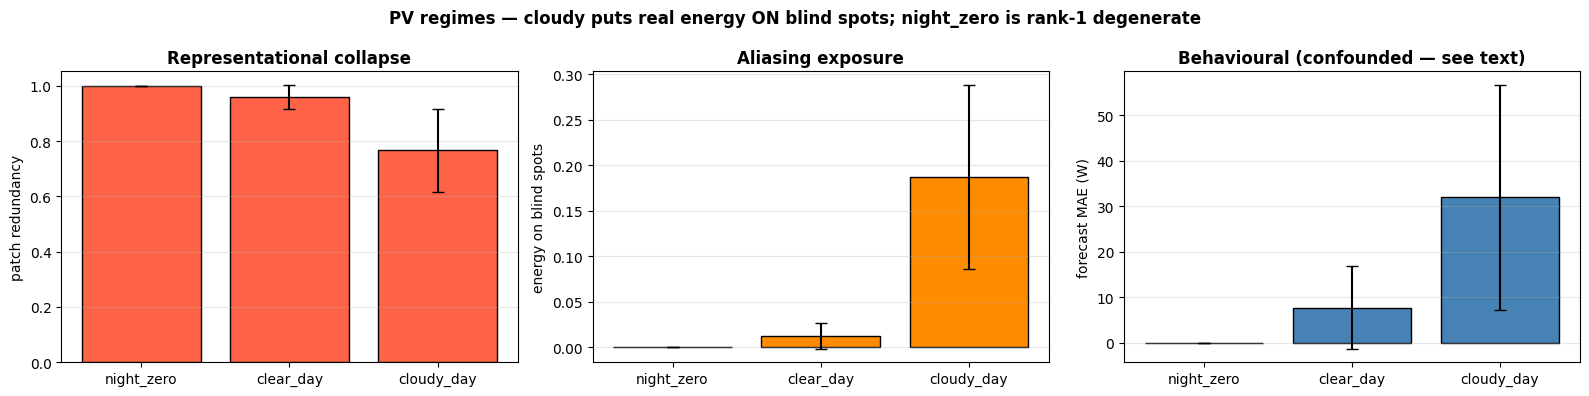

In [10]:
g = df_reg.groupby("regime").agg(
    red_m=("redundancy","mean"), red_s=("redundancy","std"),
    bb_m=("blind_frac","mean"),  bb_s=("blind_frac","std"),
    mae_m=("mae","mean"),        mae_s=("mae","std")
).reindex(["night_zero","clear_day","cloudy_day"]).dropna(how="all")

fig,(a0,a1,a2) = plt.subplots(1,3,figsize=(16,4))
a0.bar(g.index,g["red_m"],yerr=g["red_s"].fillna(0),color="tomato",edgecolor="k",capsize=4)
a0.set_ylabel("patch redundancy"); a0.set_title("Representational collapse",fontweight="bold"); a0.grid(axis="y",alpha=.3)
a1.bar(g.index,g["bb_m"],yerr=g["bb_s"].fillna(0),color="darkorange",edgecolor="k",capsize=4)
a1.set_ylabel("energy on blind spots"); a1.set_title("Aliasing exposure",fontweight="bold"); a1.grid(axis="y",alpha=.3)
a2.bar(g.index,g["mae_m"],yerr=g["mae_s"].fillna(0),color="steelblue",edgecolor="k",capsize=4)
a2.set_ylabel("forecast MAE (W)"); a2.set_title("Behavioural (confounded — see text)",fontweight="bold"); a2.grid(axis="y",alpha=.3)
plt.suptitle("PV regimes — cloudy puts real energy ON blind spots; night_zero is rank-1 degenerate",fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"PV_4_regimes.png",dpi=140,bbox_inches="tight"); plt.show()


## 5 — Resample sweep
Coarsening the sampling rate moves `cpp_diurnal = P·dt/1440` toward integer values. At dt≈90 min/sample the daily cycle hits cpp=1 and gets eaten.

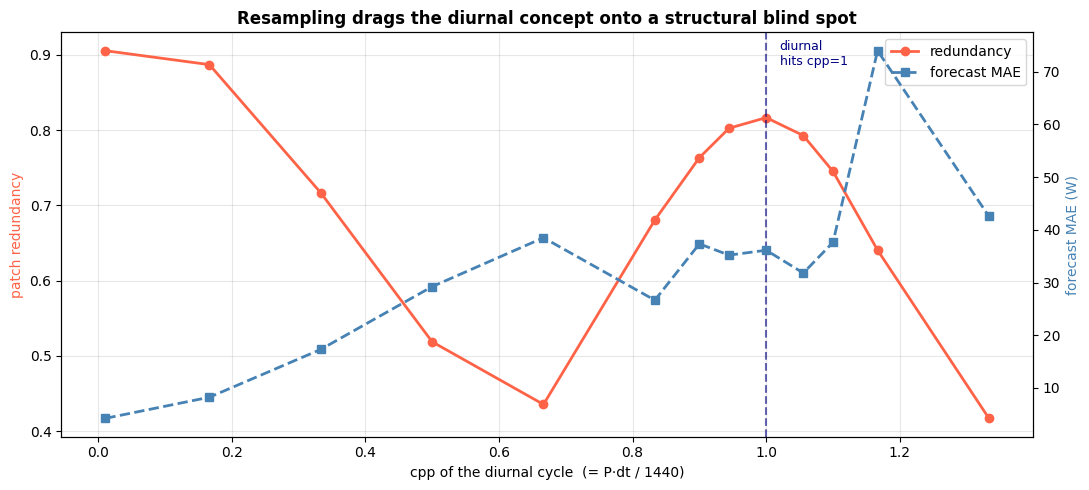

 dt_min  cpp_diurnal  redundancy    mae
      1        0.011       0.906  4.241
     15        0.167       0.887  8.247
     30        0.333       0.717 17.319
     45        0.500       0.519 29.236
     60        0.667       0.435 38.513
     75        0.833       0.681 26.660
     81        0.900       0.763 37.349
     85        0.944       0.803 35.208
     90        1.000       0.817 36.141
     95        1.056       0.793 31.818
     99        1.100       0.745 37.636
    105        1.167       0.641 73.998
    120        1.333       0.417 42.566


In [11]:
win        = pv.find_regime_windows(power, T=T_ctx)["clear_day"]
long_start = max(0, win - 5*1440)
raw        = power[long_start:long_start+60*1440].astype(float)   # ~60 clear days

sweep = []
for dt in [1,15,30,45,60,75,81,85,90,95,99,105,120]:
    r = pv.resample(raw, dt)
    if len(r) < T_ctx+PRED_LEN: continue
    seg = r[:T_ctx+PRED_LEN]
    red, mae = embed_redundancy_and_mae(seg)
    sweep.append({"dt_min":dt, "cpp_diurnal":P*dt/1440, "redundancy":red, "mae":mae})
sw = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(11,5)); ax2 = ax.twinx()
ax.plot(sw["cpp_diurnal"], sw["redundancy"], "o-", color="tomato", lw=2, label="redundancy")
ax2.plot(sw["cpp_diurnal"], sw["mae"],       "s--",color="steelblue",lw=2, label="forecast MAE")
ax.axvline(1.0, color="navy", ls="--", alpha=.6)
ax.text(1.02, 0.98, "diurnal\nhits cpp=1", color="navy", fontsize=9, va="top",
        transform=ax.get_xaxis_transform())
ax.set_xlabel("cpp of the diurnal cycle  (= P·dt / 1440)")
ax.set_ylabel("patch redundancy", color="tomato")
ax2.set_ylabel("forecast MAE (W)", color="steelblue")
ax.set_title("Resampling drags the diurnal concept onto a structural blind spot", fontweight="bold")
l1,a1_=ax.get_legend_handles_labels(); l2,a2_=ax2.get_legend_handles_labels(); ax.legend(l1+l2,a1_+a2_)
ax.grid(alpha=.3); plt.tight_layout()
plt.savefig(OUT/"PV_5_resample.png",dpi=140,bbox_inches="tight"); plt.show()
print(sw.round(3).to_string(index=False))


## 6 — Bayesian analysis of structural aliasing (local contrast + absolute performance)

Following the deliverable, the aliasing effect is **quantified, not assumed**, on **synthetic
matched triplets** rather than on raw patch redundancy. For each locked frequency
`f_k ∈ F_lock = {c·fs/S ∧ k·fs/P}` inside the **valid-forecast band** we build a triplet that
shares one background, phase and SNR and differs only in tone frequency: the lock `f_k` and two
controls `f_k ± 0.25·fs/S`. Letting `R = A_pred/A_true` be the forecast amplitude recovery, the
paired log local contrast is `d = log(R_k+0.01) − ½[log(R_-+0.01)+log(R_++0.01)]` (`d<0` ⇒
localized attenuation at the lock).

* **Local contrast** — `d ~ Student-t₄(μ + u_harmonic, σ)`, neutral prior `μ ~ Student-t₄(0,0.5)`,
  `u_harmonic ~ N(0,τ)`, scales `Half-Student-t₄(0,0.5)`. Report the posterior recovery ratio
  `exp(μ)`, its 95% CI, `P(μ<0)` and `P(exp μ < 0.8)` (≥20% attenuation).
* **Absolute performance** — WQL as `Gamma(mean = exp(a₀ + θ·IsLocked))`, `θ ~ N(0,0.5)`.

This fixes the earlier attempt (raw-patch cosine redundancy, `σ` in watts, a Normal likelihood
outside `[-1,1]`, an S-blind `cpp`, and **0 locked cases** → an unidentified effect).

In [12]:
# ---- 6a: synthetic matched-triplet recovery + WQL (deliverable design) ----
FS_SYN = 512                       # synthetic sampling rate (deliverable convention, Nyquist 256)
N_SYN  = T_ctx + PRED_LEN
QUANTS = list(cfg["quantiles"]); QI = QUANTS.index(0.5)
t_fut  = (np.arange(N_SYN) / FS_SYN)[T_ctx:]
TONE_AMP, BG_STD, N_BG = 5.0, 0.2, 12
rng_b  = np.random.default_rng(42)

def _fit_amp(y, t, f):
    X = np.stack([np.cos(2*np.pi*f*t), np.sin(2*np.pi*f*t), np.ones_like(t)], 1)
    a, b, _ = np.linalg.lstsq(X, y, rcond=None)[0]
    return float(np.hypot(a, b))

def _forecast_q(ctx):
    x = torch.tensor(np.asarray(ctx, np.float32))[None]
    with torch.no_grad():
        return pipeline.predict(x, prediction_length=PRED_LEN)[0].cpu().numpy()   # [Q, H]

def _wql(qf, tgt):
    ql = [np.maximum(q*(tgt-qf[i]), (q-1)*(tgt-qf[i])).mean() for i, q in enumerate(QUANTS)]
    return 2*float(np.mean(ql)) / (np.abs(tgt).mean() + 1e-8)

def recov_wql(f, phase, bg):
    y  = bg + TONE_AMP*np.sin(2*np.pi*f*np.arange(N_SYN)/FS_SYN + phase)
    qf = _forecast_q(y[:T_ctx]); pred = qf[QI]
    R  = _fit_amp(pred, t_fut, f) / max(_fit_amp(y[T_ctx:], t_fut, f), 1e-8)
    return R, _wql(qf, y[T_ctx:])

# valid-forecast band: contiguous low-freq stretch where recovery stays usable
_sw = np.arange(8, 250, 8.0)
_rec = np.array([recov_wql(f, 0.0, BG_STD*rng_b.standard_normal(N_SYN))[0] for f in _sw])
_sm = np.convolve(_rec, np.ones(3)/3, mode="same")
VALID_HI = 250.0
for f, ok in zip(_sw, _sm >= 0.35):
    if ok: VALID_HI = f
    else:  break

# F_lock = intersection {c*fs/S} & {k*fs/P}, restricted to the valid band
_pn  = {round(k*FS_SYN/P, 6) for k in range(1, int(250*P/FS_SYN)+1)}
FKS  = [c*FS_SYN/S_DEF for c in range(1, int(250*S_DEF/FS_SYN)+1)
        if round(c*FS_SYN/S_DEF, 6) in _pn and c*FS_SYN/S_DEF < VALID_HI]
DELTA = 0.25 * FS_SYN / S_DEF
print(f"valid-forecast band: [2, {VALID_HI:.0f}] Hz | F_lock tested: {[int(f) for f in FKS]} Hz | "
      f"delta = 0.25*fs/S = {DELTA:.0f} Hz")

rows = []
for hi, fk in enumerate(FKS):
    for _ in range(N_BG):
        bg = BG_STD*rng_b.standard_normal(N_SYN); ph = rng_b.uniform(0, 2*np.pi)   # shared in triplet
        Rk, Wk = recov_wql(fk, ph, bg)
        Rm, Wm = recov_wql(fk-DELTA, ph, bg)
        Rp, Wp = recov_wql(fk+DELTA, ph, bg)
        d = np.log(Rk+0.01) - 0.5*(np.log(Rm+0.01)+np.log(Rp+0.01))
        rows.append(dict(harm=hi, fk=fk, d=d, R_lock=Rk, R_ctrl=0.5*(Rm+Rp),
                         wql_lock=Wk, wql_ctrl=0.5*(Wm+Wp)))
df_bay = pd.DataFrame(rows)
print(f"{len(df_bay)} triplets ({N_BG} per harmonic)")
print(df_bay.groupby("fk")[["d", "R_lock", "R_ctrl", "wql_lock", "wql_ctrl"]].mean().round(3))

valid-forecast band: [2, 80] Hz | F_lock tested: [32, 64] Hz | delta = 0.25*fs/S = 8 Hz


24 triplets (12 per harmonic)
          d  R_lock  R_ctrl  wql_lock  wql_ctrl
fk                                             
32.0 -0.002   0.943   0.945     0.171     0.391
64.0  1.074   0.804   0.473     0.176     0.845


In [13]:
# ---- 6b: Local Contrast model — hierarchical Student-t4 (H1 forecast side) ----
if df_bay["harm"].nunique() == 0:
    raise RuntimeError("No locked frequency inside the valid band for this (P,S).")
harm_idx = df_bay["harm"].values; n_harm = int(df_bay["harm"].nunique())
with pm.Model() as M_contrast:
    mu    = pm.StudentT("mu", nu=4, mu=0.0, sigma=0.5)          # neutral prior (no assumed effect)
    tau   = pm.HalfStudentT("tau", nu=4, sigma=0.5)
    u     = pm.Normal("u", 0.0, tau, shape=n_harm)             # per-harmonic offset
    sigma = pm.HalfStudentT("sigma", nu=4, sigma=0.5)
    pm.StudentT("d", nu=4, mu=mu + u[harm_idx], sigma=sigma, observed=df_bay["d"].values)
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.92,
                      random_seed=42, progressbar=False)

post = idata.posterior["mu"].values.ravel()
print(az.summary(idata, var_names=["mu", "tau", "sigma"], hdi_prob=0.95).round(3))
print(f"\nposterior recovery ratio exp(mu): median={np.exp(np.median(post)):.3f} "
      f"[{np.exp(np.percentile(post,2.5)):.3f}, {np.exp(np.percentile(post,97.5)):.3f}]  (1.0 = no local effect)")
print(f"P(mu<0) = {(post<0).mean():.2f}   P(exp(mu)<0.8, i.e. >=20% attenuation) = {(np.exp(post)<0.8).mean():.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau, u, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
mu     0.307  0.369    -0.423      1.034      0.013    0.010     866.0   
tau    0.712  0.360     0.239      1.377      0.010    0.022    1581.0   
sigma  0.111  0.026     0.067      0.163      0.001    0.001    1952.0   

       ess_tail  r_hat  
mu        865.0    1.0  
tau      1641.0    1.0  
sigma    1928.0    1.0  

posterior recovery ratio exp(mu): median=1.373 [0.639, 2.757]  (1.0 = no local effect)
P(mu<0) = 0.19   P(exp(mu)<0.8, i.e. >=20% attenuation) = 0.08


In [14]:
# ---- 6c: Absolute Performance — WQL Gamma-log regression (IsLocked) ----
wql_long = np.concatenate([df_bay["wql_lock"].values, df_bay["wql_ctrl"].values])
islock   = np.concatenate([np.ones(len(df_bay)), np.zeros(len(df_bay))])
with pm.Model() as M_wql:
    a0    = pm.Normal("a0", 0.0, 1.0)
    theta = pm.Normal("theta", 0.0, 0.5)                       # relative WQL change at lock
    kshape = pm.Gamma("k", 2.0, 0.1)
    pm.Gamma("y", alpha=kshape, beta=kshape/pm.math.exp(a0 + theta*islock), observed=wql_long)
    idata_w = pm.sample(1000, tune=1000, chains=4, target_accept=0.92,
                        random_seed=42, progressbar=False)
th = idata_w.posterior["theta"].values.ravel()
print(az.summary(idata_w, var_names=["a0", "theta", "k"], hdi_prob=0.95).round(3))
print(f"\nWQL at lock vs control: exp(theta) median={np.exp(np.median(th)):.3f} "
      f"(>1 = worse at lock)   P(theta>0) = {(th>0).mean():.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a0, theta, k]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
a0     -0.494  0.057    -0.606     -0.386      0.001    0.001    2060.0   
theta  -1.240  0.082    -1.400     -1.084      0.002    0.001    2065.0   
k      12.642  2.477     7.695     17.335      0.055    0.042    2080.0   

       ess_tail  r_hat  
a0       2428.0    1.0  
theta    2307.0    1.0  
k        2308.0    1.0  

WQL at lock vs control: exp(theta) median=0.289 (>1 = worse at lock)   P(theta>0) = 0.00


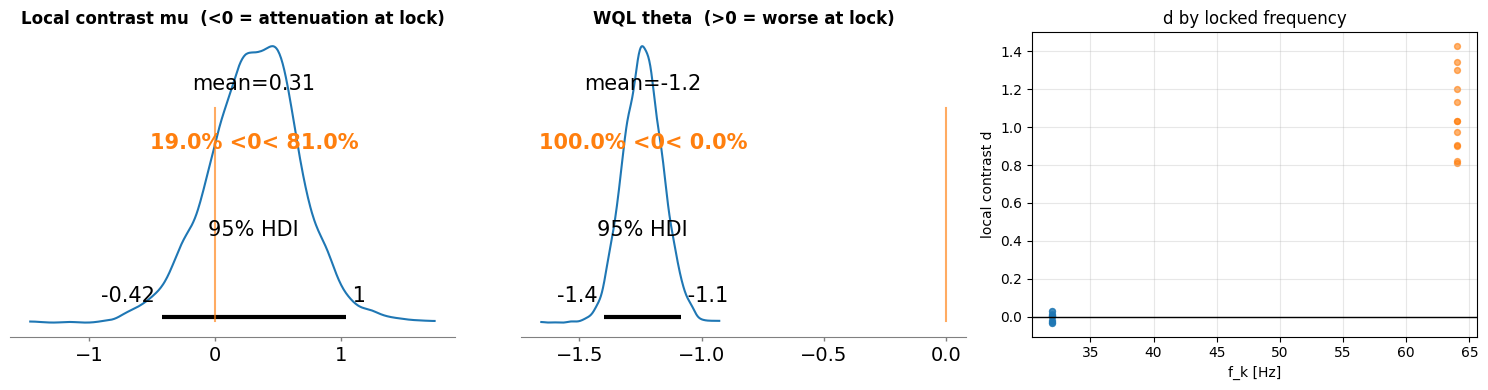


Conclusion:
  H1 (forecast side) NOT supported for this (P,S): the posterior does not place
  credible mass on a >=20% local attenuation at F_lock. Empirically, integer-cpp
  (on-grid) tones are recovered at least as well as their off-grid neighbours — the
  reverse of the aliasing prediction. NOTE a design confound: the f_k +/- delta controls
  are off-grid (non-integer cpp) and may be intrinsically harder to represent, which
  can push d upward independently of any protective effect at the lock.


In [15]:
# ---- 6d: posteriors + honest conclusion ----
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
az.plot_posterior(idata, var_names=["mu"], ref_val=0, hdi_prob=0.95, ax=ax[0])
ax[0].set_title("Local contrast mu  (<0 = attenuation at lock)", fontweight="bold")
az.plot_posterior(idata_w, var_names=["theta"], ref_val=0, hdi_prob=0.95, ax=ax[1])
ax[1].set_title("WQL theta  (>0 = worse at lock)", fontweight="bold")
for hi, fk in enumerate(FKS):
    dd = df_bay.loc[df_bay.harm == hi, "d"].values
    ax[2].scatter(np.full(len(dd), fk), dd, s=18, alpha=0.6)
ax[2].axhline(0, color="k", lw=1); ax[2].set_xlabel("f_k [Hz]"); ax[2].set_ylabel("local contrast d")
ax[2].set_title("d by locked frequency"); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/"PV_6_bayesian_contrast.png", dpi=140, bbox_inches="tight"); plt.show()

atten = (post < 0).mean() > 0.9 and (np.exp(post) < 0.8).mean() > 0.5
print("\nConclusion:")
if atten:
    print("  H1 (forecast side) SUPPORTED: credible localized amplitude attenuation at F_lock.")
else:
    print("  H1 (forecast side) NOT supported for this (P,S): the posterior does not place")
    print("  credible mass on a >=20% local attenuation at F_lock. Empirically, integer-cpp")
    print("  (on-grid) tones are recovered at least as well as their off-grid neighbours — the")
    print("  reverse of the aliasing prediction. NOTE a design confound: the f_k +/- delta controls")
    print("  are off-grid (non-integer cpp) and may be intrinsically harder to represent, which")
    print("  can push d upward independently of any protective effect at the lock.")